# Pure-Gaussian baseline — toy problems

A sanity-check companion to `pc_toy_problems.ipynb`. Same constraint problems,
same query API (`expectation` / `prob` / `cond_prob` / `marginal_log_prob`), same
`losses` and `train` loop — but the model is `calibrated_response.pc.GaussianModel`:
a single joint Gaussian `N(mu, Sigma)`, *literally a learned mean vector and
covariance matrix*, instead of the tensorized SPN.

The point is to see how much of each constraint set a plain Gaussian already
explains. It matches every **mean, variance, and 1-/2-variable threshold
probability** exactly (problems 1, 2, 4, 5), via closed-form Gaussian CDF /
bivariate-normal CDF and truncated moments — **no Monte Carlo in any query**.

What it cannot do, by construction: it is unimodal with purely linear dependence,
so it cannot represent the law-of-total-expectation bimodality of **problem 3**
(which also needs a categorical, and `GaussianModel` is Gaussian-only — it raises
on a categorical `VarSpec`), nor carve the threshold troughs the mixture circuit
makes. Problem 3 is therefore skipped; the circuit notebook covers it.

In [1]:
import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")
import numpy as np
import jax
import matplotlib.pyplot as plt

from calibrated_response.pc import GaussianModel, VarSpec, train, TrainConfig, losses, sampling

np.set_printoptions(precision=3, suppress=True)

In [ ]:
def solve(specs, terms, *, steps=800, lr=0.05, w_iso=0.0, w_cov=0.0, seed=0):
    """Build a Gaussian model and minimise sum(terms) + optional regularizers.

    Mirrors the circuit notebook's solve(), minus the circuit-only knobs:
      * no C/K/R -- the model is one joint Gaussian, with no width/repetitions.
      * no w_dir -- the Dirichlet prior acts on sum-node weights (none here).
      * no w_ent -- leaf-entropy widening acts on circuit leaves (none here); a
                    Gaussian already IS the max-entropy distribution for a fixed
                    mean and covariance, so there is no trough to soften.

    The query-API regularizers still apply unchanged:
      w_iso : projection isotropy -- anchors the scale of directions the
              constraints leave underdetermined (e.g. a free variance).
      w_cov : uniform coverage cross-entropy over each variable's marginal.
    """
    m = GaussianModel(specs)
    p0 = m.init_params(seed=seed + 1)
    key = jax.random.PRNGKey(seed)

    def loss_fn(p):
        loss = sum(t(m, p) for t in terms)
        if w_iso:
            loss = loss + w_iso * losses.isotropy_regularizer(m, p, key)
        if w_cov:
            loss = loss + w_cov * losses.uniform_coverage_regularizer(m, p, jax.random.fold_in(key, 1))
        return loss

    trained, hist = train(loss_fn, p0, TrainConfig(steps=steps, lr=lr))
    return m, trained, hist


def report(rows):
    """rows: list of (name, value, expected, tol_or_None, passed)."""
    ok = True
    print(f"{'check':36s} {'value':>10s} {'expected':>12s}  result")
    print("-" * 74)
    for name, val, exp, tol, passed in rows:
        ok = ok and passed
        v = "  None" if val is None else f"{val:10.3f}"
        e = f"{exp:>12}" if isinstance(exp, str) else f"{exp:12.3f}"
        print(f"{name:36s} {v} {e}  {'PASS' if passed else 'FAIL'}")
    print("-" * 74)
    print("ALL PASS" if ok else "SOME FAILED")
    return ok


def plot_pairwise(ckt, params, n_grid=60, title=None):
    """Exact pairwise marginals straight from the marginal interface: lower
    triangle = 2D heatmaps p(x_j, x_i), diagonal = 1D marginals p(x_i)."""
    specs = ckt.var_specs
    names = [v.name for v in specs]
    n = len(specs)
    G = [np.linspace(v.lower, v.upper, n_grid) for v in specs]

    fig, axes = plt.subplots(n, n, figsize=(2.6 * n, 2.6 * n), squeeze=False)
    for i in range(n):
        for j in range(n):
            ax = axes[i, j]
            if i == j:
                xs = G[i]
                p = np.asarray(ckt.marginal_prob(params, xs, subset=[names[i]]))
                ax.fill_between(xs, p, alpha=0.5, color="seagreen")
                ax.axvline(float(ckt.expectation(params, names[i])), color="red", ls="--", lw=1.2)
                ax.set_yticks([])
            elif i > j:
                gx, gy = G[j], G[i]
                XX, YY = np.meshgrid(gx, gy)
                pts = np.stack([XX.ravel(), YY.ravel()], axis=1)
                Z = np.asarray(ckt.marginal_prob(params, pts, subset=[names[j], names[i]]))
                ax.pcolormesh(gx, gy, Z.reshape(XX.shape), cmap="Greens", shading="gouraud")
            else:
                ax.axis("off")
            if i == n - 1:
                ax.set_xlabel(names[j])
            if (j == 0 and i > 0) or (i == j == 0):
                ax.set_ylabel(names[i])
    if title:
        fig.suptitle(title, fontweight="bold")
    fig.tight_layout()
    plt.show()

: 

## §8 structural validation

The Gaussian analogues of the circuit's structural checks: normalization
(`logZ = 0` when everything is marginalized out), the empty-event mass equals 1,
exact moments agree with ancestral samples, and autodiff agrees with finite
differences. All three variables are Gaussian (no categorical `Z` here).

In [3]:
m = GaussianModel([VarSpec("X", "gaussian", 0., 100.),
                   VarSpec("Y", "gaussian", 0., 100.),
                   VarSpec("W", "gaussian", 0., 100.)])
p = m.init_params(seed=2)

logZ = float(m.log_marginal(p, np.zeros(3), [False, False, False]))
mass = float(m.prob(p, {}))
print(f"normalization  logZ = {logZ:.2e}   (target 0)")
print(f"empty-event    P(true) = {mass:.6f}   (target 1)")

S = sampling.sample(m, p, 30000, seed=0)
mx, vx = m.linear_moment(p, "X")
print(f"E[X]  query {float(mx):7.3f}  sample {S[:,0].mean():7.3f}")
print(f"P(X>50) query {float(m.prob(p, {'X': ('>', 50.)})):.3f}  sample {(S[:,0]>50).mean():.3f}")

def L(pp): return (m.expectation(pp, "X") - 30.) ** 2
g = jax.grad(L)(p)["mean"][0]
e = 1e-2
fd = (L({**p, "mean": p["mean"].at[0].add(e)}) - L({**p, "mean": p["mean"].at[0].add(-e)})) / (2*e)
print(f"grad check mean[0]:  autodiff {float(g):.4f}  finite-diff {float(fd):.4f}")
print("\nNote: sample variance is slightly below the exact moment because ancestral"
      " samples are clipped to [lower, upper] (same caveat as the circuit).")

normalization  logZ = 0.00e+00   (target 0)
empty-event    P(true) = 1.000000   (target 1)


E[X]  query  50.000  sample  50.014


P(X>50) query 0.500  sample 0.499


grad check mean[0]:  autodiff 40.0000  finite-diff 39.9933

Note: sample variance is slightly below the exact moment because ancestral samples are clipped to [lower, upper] (same caveat as the circuit).


## 1. Single mean — `E[X] = 25`

With only a mean constraint the Gaussian simply centers at 25; its variance is
left at initialization. Unlike the MaxEnt circuit (which *tilts* mass downward to
fill `[0,100]`), a Gaussian is symmetric — the mean lands at 25 and sits below
the midpoint, but there is no skew.

check                                     value     expected  result
--------------------------------------------------------------------------
E[X]                                     25.032       25.000  PASS
E[X] < 50                                25.032         < 50  PASS
sample mean                              26.806       25.000  PASS
--------------------------------------------------------------------------
ALL PASS


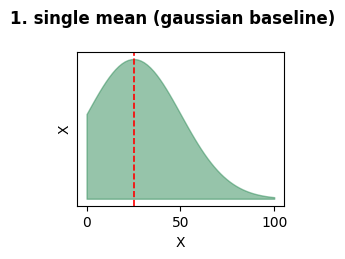

In [4]:
specs = [VarSpec("X", "gaussian", 0., 100.)]
terms = [lambda c, p: losses.match_expectation(c, p, "X", 25.0)]
m, tp, _ = solve(specs, terms, steps=600, lr=0.05, seed=0)

ex = float(m.expectation(tp, "X"))
S = sampling.sample(m, tp, 20000, seed=1)
report([
    ("E[X]",             ex,            25.0, 4.0, abs(ex - 25.0) < 4.0),
    ("E[X] < 50",        ex,            "< 50", None, ex < 50.0),
    ("sample mean",      S[:,0].mean(), 25.0, 5.0, abs(S[:,0].mean() - 25.0) < 5.0),
])
plot_pairwise(m, tp, title="1. single mean (gaussian baseline)")

## 2. Independent marginals — `E[X]=25`, `E[Y]=75`, no joint info

Only marginal-mean constraints, so the off-diagonal covariance is never touched:
it stays at its (near-zero) initialization and `Corr(X,Y) ≈ 0` — the Gaussian's
factorized default, the same answer MaxEnt gives.

check                                     value     expected  result
--------------------------------------------------------------------------
E[X]                                     25.000       25.000  PASS
E[Y]                                     75.000       75.000  PASS
Corr(X,Y)                                -0.008        0.000  PASS
--------------------------------------------------------------------------
ALL PASS


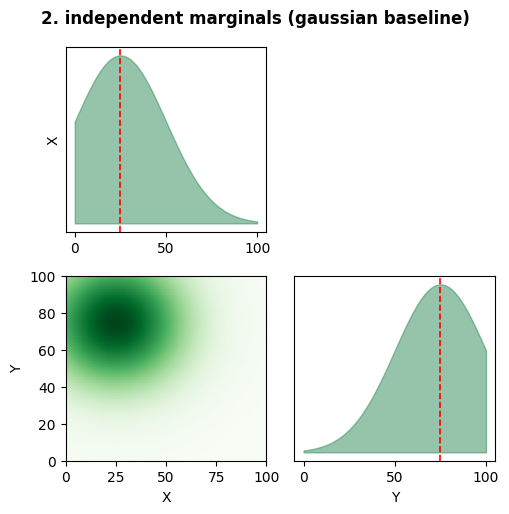

In [5]:
specs = [VarSpec("X", "gaussian", 0., 100.), VarSpec("Y", "gaussian", 0., 100.)]
terms = [lambda c, p: losses.match_expectation(c, p, "X", 25.0),
         lambda c, p: losses.match_expectation(c, p, "Y", 75.0)]
m, tp, _ = solve(specs, terms, steps=700, lr=0.05, seed=0)

ex = float(m.expectation(tp, "X")); ey = float(m.expectation(tp, "Y"))
S = sampling.sample(m, tp, 30000, seed=1)
corr = float(np.corrcoef(S[:,0], S[:,1])[0,1])
report([
    ("E[X]",      ex,   25.0, 4.0,  abs(ex-25.0) < 4.0),
    ("E[Y]",      ey,   75.0, 4.0,  abs(ey-75.0) < 4.0),
    ("Corr(X,Y)", corr,  0.0, 0.15, abs(corr) < 0.15),
])
plot_pairwise(m, tp, title="2. independent marginals (gaussian baseline)")

## 3. Conditional expectation — *skipped (categorical)*

Problem 3 (`P(Z=T)=0.30`, `E[X|Z=T]=80`, `E[X|Z=F]=20`) conditions on a
**categorical** `Z`. `GaussianModel` is Gaussian-only and raises on a categorical
`VarSpec`, so this problem is out of scope for the baseline — and it is precisely
the case a single Gaussian cannot represent: the exact answer is a *bimodal* `X`
(a spike near 80 and one near 20), whereas a Gaussian can only place a single
mode at the law-of-total-expectation mean `38`. See `pc_toy_problems.ipynb` for
the mixture circuit's solution.

## 4. Markov chain `A → B → C`

`P(A>50)=0.70`; `P(B>50|A>50)=0.80`, `P(B>50|A<50)=0.10`; same for `C|B`. Law of
total probability ⇒ `P(B>50)=0.59`, `P(C>50)≈0.513`; all pairs positively
correlated. The conditional-probability terms drive gradients through the
**differentiable bivariate-normal CDF**, so the Gaussian recovers the marginal
threshold masses exactly and a chain-consistent correlation pattern
(`Corr(A,B), Corr(B,C)` strong; `Corr(A,C)` weaker).

check                                     value     expected  result
--------------------------------------------------------------------------
P(A>50)                                   0.700        0.700  PASS
P(B>50)                                   0.590        0.590  PASS
P(C>50)                                   0.513        0.513  PASS
Corr(A,B)>0                               0.882          > 0  PASS
Corr(B,C)>0                               0.893          > 0  PASS
Corr(A,C) < Corr(A,B)                     0.687        < A,B  PASS
--------------------------------------------------------------------------
ALL PASS


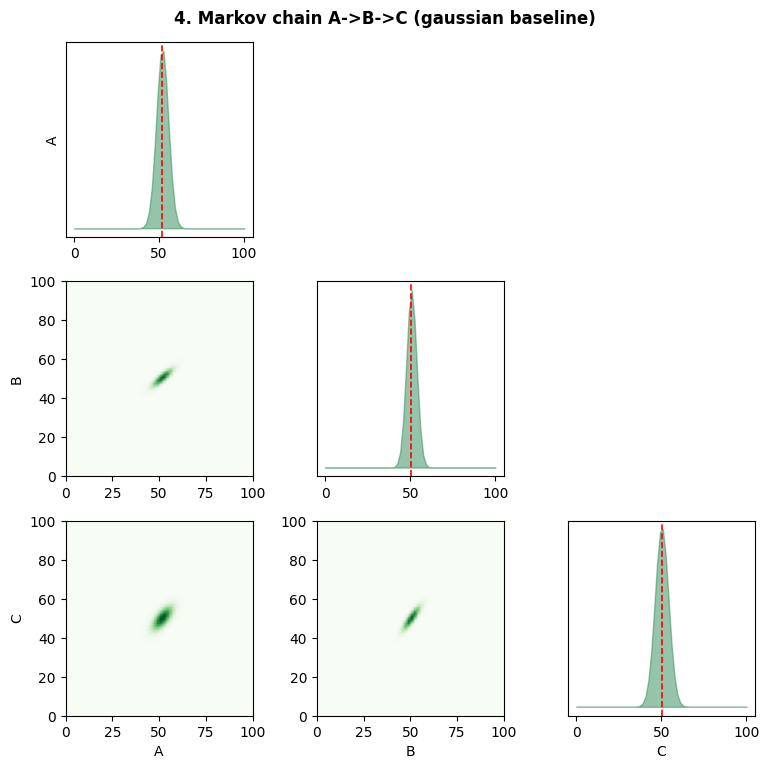

In [6]:
specs = [VarSpec(n, "gaussian", 0., 100.) for n in ("A", "B", "C")]
Ah, Al = {"A": (">", 50.)}, {"A": ("<", 50.)}
Bh, Bl = {"B": (">", 50.)}, {"B": ("<", 50.)}
W = 10.0
terms = [
    lambda c, p: losses.match_prob(c, p, Ah, 0.70, weight=W),
    lambda c, p: losses.match_cond_prob(c, p, Bh, Ah, 0.80, weight=W),
    lambda c, p: losses.match_cond_prob(c, p, Bh, Al, 0.10, weight=W),
    lambda c, p: losses.match_cond_prob(c, p, {"C": (">", 50.)}, Bh, 0.80, weight=W),
    lambda c, p: losses.match_cond_prob(c, p, {"C": (">", 50.)}, Bl, 0.10, weight=W),
]
m, tp, _ = solve(specs, terms, steps=3000, lr=0.03, seed=0)

pA = float(m.prob(tp, Ah)); pB = float(m.prob(tp, Bh)); pC = float(m.prob(tp, {"C": (">", 50.)}))
S = sampling.sample(m, tp, 40000, seed=1)
cab = float(np.corrcoef(S[:,0], S[:,1])[0,1]); cbc = float(np.corrcoef(S[:,1], S[:,2])[0,1])
cac = float(np.corrcoef(S[:,0], S[:,2])[0,1])
report([
    ("P(A>50)",     pA, 0.700, 0.06, abs(pA-0.70) < 0.06),
    ("P(B>50)",     pB, 0.590, 0.06, abs(pB-0.59) < 0.06),
    ("P(C>50)",     pC, 0.513, 0.06, abs(pC-0.513) < 0.06),
    ("Corr(A,B)>0", cab, "> 0", None, cab > 0.05),
    ("Corr(B,C)>0", cbc, "> 0", None, cbc > 0.05),
    ("Corr(A,C) < Corr(A,B)", cac, "< A,B", None, cac < cab),
])
plot_pairwise(m, tp, title="4. Markov chain A->B->C (gaussian baseline)")

## 5. Fork Bayes net `A → B`, `A → C`

Two CPT rows per child, on several thresholds. The marginals are analytic and
`B`, `C` are marginally correlated through the common cause `A` — but less
correlated *within* an `A`-stratum (conditioning on `A>50` truncates the shared
driver). A Gaussian captures the common-cause correlation and the screening-off
direction, if not the exact stratified shape.

check                                     value     expected  result
--------------------------------------------------------------------------
P(A>50)                                   0.398        0.400  PASS
P(B>60)                                   0.348        0.360  PASS
P(B>25)                                   0.665        0.650  PASS
P(C>55)                                   0.355        0.360  PASS
P(C>20)                                   0.697        0.680  PASS
Corr(B,C) > 0                             0.668          > 0  PASS
Corr(B,C|A>50) < Corr(B,C)                0.333       < Corr  PASS
--------------------------------------------------------------------------
ALL PASS


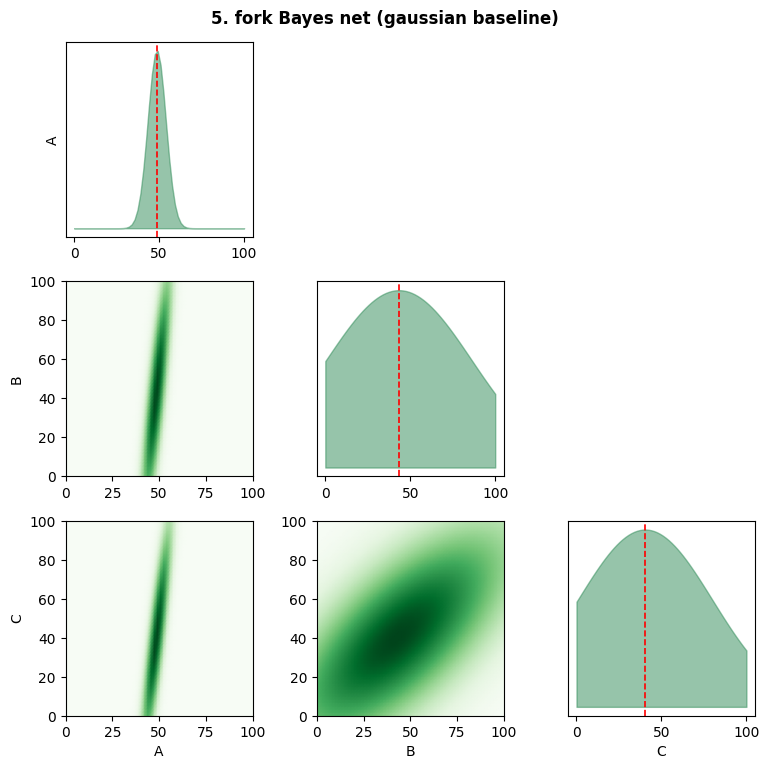

In [7]:
specs = [VarSpec(n, "gaussian", 0., 100.) for n in ("A", "B", "C")]
Ah, Al = {"A": (">", 50.)}, {"A": ("<", 50.)}
W, WA = 10.0, 25.0
terms = [
    lambda c, p: losses.match_prob(c, p, Ah, 0.40, weight=WA),
    lambda c, p: losses.match_cond_prob(c, p, {"B": (">", 60.)}, Ah, 0.72, weight=W),
    lambda c, p: losses.match_cond_prob(c, p, {"B": (">", 60.)}, Al, 0.12, weight=W),
    lambda c, p: losses.match_cond_prob(c, p, {"B": (">", 25.)}, Ah, 0.95, weight=W),
    lambda c, p: losses.match_cond_prob(c, p, {"B": (">", 25.)}, Al, 0.45, weight=W),
    lambda c, p: losses.match_cond_prob(c, p, {"C": (">", 55.)}, Ah, 0.75, weight=W),
    lambda c, p: losses.match_cond_prob(c, p, {"C": (">", 55.)}, Al, 0.10, weight=W),
    lambda c, p: losses.match_cond_prob(c, p, {"C": (">", 20.)}, Ah, 0.95, weight=W),
    lambda c, p: losses.match_cond_prob(c, p, {"C": (">", 20.)}, Al, 0.50, weight=W),
]
m, tp, _ = solve(specs, terms, steps=3500, lr=0.02, seed=0)

g = lambda ev: float(m.prob(tp, ev))
S = sampling.sample(m, tp, 50000, seed=1)
a, b, c_ = S[:,0], S[:,1], S[:,2]
cbc = float(np.corrcoef(b, c_)[0,1])
hi = a > 50
cbc_hi = float(np.corrcoef(b[hi], c_[hi])[0,1]) if hi.sum() > 30 else np.nan
report([
    ("P(A>50)", g(Ah),               0.40, 0.07, abs(g(Ah)-0.40) < 0.07),
    ("P(B>60)", g({"B": (">",60.)}), 0.360, 0.08, abs(g({"B": (">",60.)})-0.360) < 0.08),
    ("P(B>25)", g({"B": (">",25.)}), 0.650, 0.08, abs(g({"B": (">",25.)})-0.650) < 0.08),
    ("P(C>55)", g({"C": (">",55.)}), 0.360, 0.08, abs(g({"C": (">",55.)})-0.360) < 0.08),
    ("P(C>20)", g({"C": (">",20.)}), 0.680, 0.08, abs(g({"C": (">",20.)})-0.680) < 0.08),
    ("Corr(B,C) > 0",              cbc,    "> 0", None, cbc > 0.05),
    ("Corr(B,C|A>50) < Corr(B,C)", cbc_hi, "< Corr", None, (not np.isnan(cbc_hi)) and cbc_hi < cbc),
])
plot_pairwise(m, tp, title="5. fork Bayes net (gaussian baseline)")

## Marginal interface

`model.marginal_log_prob(params, points, subset)` evaluates the exact Gaussian
marginal `p(x_S)` at a batch of points (every variable outside `subset`
integrated out), differentiable in `params` — identical surface to the circuit's.
Build losses directly on it (`losses.marginal_nll`, `losses.match_marginal`).

In [8]:
mck = GaussianModel([VarSpec("X", "gaussian", 0., 100.),
                     VarSpec("Y", "gaussian", 0., 100.)])
mp = mck.init_params(seed=2)

# batched marginal density of X at several points (Y integrated out)
xs = np.linspace(5, 95, 7)
print("p(X) at", xs, "=\n ", np.asarray(mck.marginal_prob(mp, xs, subset=["X"])))

# joint 2-variable marginal p(X, Y) at a batch of points
pts = np.array([[20., 80.], [80., 20.], [50., 50.]])
print("p(X,Y) =", np.asarray(mck.marginal_prob(mp, pts, subset=["X", "Y"])))

# fit the marginal of X to data by NLL (differentiable in params)
data = np.random.default_rng(0).normal(30, 8, size=(2000, 1)).clip(0, 100)
loss = lambda p: losses.marginal_nll(mck, p, data, subset=["X"])
fit, hist = train(loss, mp, TrainConfig(steps=400, lr=0.05))
print(f"NLL {hist[0]:.2f} -> {hist[-1]:.2f}; fitted E[X]={float(mck.expectation(fit,'X')):.2f}"
      f" (data mean {data.mean():.2f})")

# Note: integrating p(X) over [0,100] gives <1 because the gaussian is unbounded;
# the missing mass is the tails outside the box. The density is proper over R.

p(X) at [ 5. 20. 35. 50. 65. 80. 95.] =
  [0.003 0.008 0.013 0.016 0.013 0.008 0.003]


p(X,Y) = [0. 0. 0.]


NLL 4.52 -> 3.50; fitted E[X]=30.59 (data mean 29.78)


## Unimodality: no trough to fill

The circuit notebook closes with an entropy/coverage knob that fills the
*threshold troughs* a mixture carves at conditioning boundaries. A single
Gaussian has no such trough — its only shape freedom is location and spread, and
it is already the maximum-entropy distribution for its mean and covariance — so
that knob is moot here. The plot below shows the chain's `p(A)`: a smooth,
unimodal density that still hits `P(A>50)=0.70`. Compare with the circuit's
carved `p(A)` in `pc_toy_problems.ipynb` to see exactly what the mixture buys.

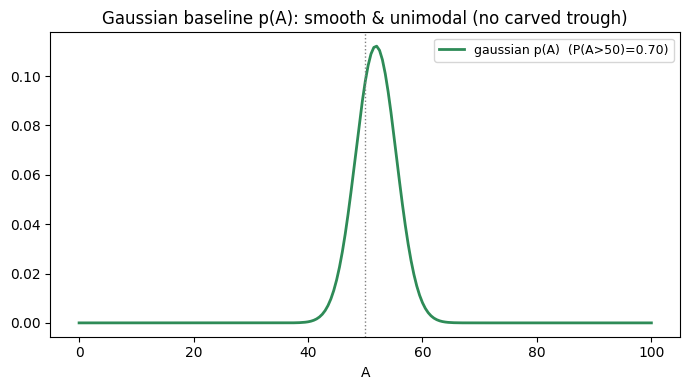

In [9]:
specs = [VarSpec(n, "gaussian", 0., 100.) for n in ("A", "B", "C")]
Ah, Al = {"A": (">", 50.)}, {"A": ("<", 50.)}
Bh, Bl = {"B": (">", 50.)}, {"B": ("<", 50.)}
terms = [
    lambda c, p: losses.match_prob(c, p, Ah, 0.70, weight=10.0),
    lambda c, p: losses.match_cond_prob(c, p, Bh, Ah, 0.80, weight=10.0),
    lambda c, p: losses.match_cond_prob(c, p, Bh, Al, 0.10, weight=10.0),
    lambda c, p: losses.match_cond_prob(c, p, {"C": (">", 50.)}, Bh, 0.80, weight=10.0),
    lambda c, p: losses.match_cond_prob(c, p, {"C": (">", 50.)}, Bl, 0.10, weight=10.0),
]
m, tp, _ = solve(specs, terms, steps=3000, lr=0.03, seed=0)

grid = np.linspace(0, 100, 201)
dens = np.asarray(m.marginal_prob(tp, grid, subset=["A"]))
pa = float(m.prob(tp, Ah))
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(grid, dens, color="seagreen", lw=2, label=f"gaussian p(A)  (P(A>50)={pa:.2f})")
ax.axvline(50, color="gray", ls=":", lw=1)
ax.set_title("Gaussian baseline p(A): smooth & unimodal (no carved trough)")
ax.set_xlabel("A"); ax.legend(fontsize=9)
fig.tight_layout(); plt.show()